# Step 3 — Aligning & scaling faces with `crop_and_align()`

Detected faces come in every orientation and size. Before they can feed a classifier or recognition
network, every face must be **centered the same way and scaled to the same size**. This notebook
implements that normalization step.

Given a detected face and its **eye locations**, we:

1. Measure the **angle** between the eyes (`eyes_angle`) and rotate so the eyes become horizontal.
2. Compute a **scaling factor** (`scaling_factor`) so the inter-eye distance matches a desired target,
   which fixes how much of the face is visible (the zoom).
3. Build a rotation+scale matrix with `cv2.getRotationMatrix2D`, shift the eye-center to its desired
   spot, and apply `cv2.warpAffine` — producing an aligned, scaled face of a fixed output size.
4. Save the aligned faces to disk.

**Two system parameters** drive everything:
- `DESIRED_SIZE` — output width/height in pixels (set by whatever network consumes the faces).
- `DESIRED_LEFT_EYE` — where the left eye should sit, as **ratios** of the output size. The right eye is
  mirrored to `1 - x`. Smaller ratios zoom out (more face visible); larger ratios zoom in.

## Imports & MTCNN detector

(`KMP_DUPLICATE_LIB_OK` must be set before importing torch/OpenCV — see Step 2.)

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # avoid PyTorch/OpenCV OpenMP clash (macOS)
os.environ.setdefault("OMP_NUM_THREADS", "1")

import cv2
import glob
import numpy as np
from math import atan2, degrees, hypot
from pathlib import Path
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN

root = Path.cwd()
while not (root / "Data").exists() and root != root.parent:
    root = root.parent
REAL_DIR = root / "Data" / "VidTIMIT"
FAKE_DIR = root / "Data" / "DeepfakeTIMIT" / "higher_quality"

detector = MTCNN(keep_all=True, device="cpu")
print("Ready. Project root:", root)

/Users/blake/opt/anaconda3/envs/deepfake-detect/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready. Project root: /Users/blake/AI Projects/Deepfake-Detection


## Reuse the face detector from Step 2

`detect_faces()` returns each face's bounding box plus **left/right eye** coordinates — the inputs
`crop_and_align()` needs.

In [2]:
def detect_faces(image_rgb):
    """Return a list of dicts: box (x,y,w,h), left_eye (x,y), right_eye (x,y), confidence."""
    boxes, probs, landmarks = detector.detect(image_rgb, landmarks=True)
    faces = []
    if boxes is None:
        return faces
    for box, prob, lm in zip(boxes, probs, landmarks):
        x1, y1, x2, y2 = (float(v) for v in box)
        faces.append({
            "box":        (x1, y1, x2 - x1, y2 - y1),
            "left_eye":   tuple(float(v) for v in lm[0]),
            "right_eye":  tuple(float(v) for v in lm[1]),
            "confidence": float(prob),
        })
    return faces

## System parameters

`DESIRED_LEFT_EYE = (0.35, 0.35)` places the left eye 35% in from the left and 35% down from the top;
by symmetry the right eye lands at `x = 0.65`. So the **desired inter-eye distance** is
`(0.65 - 0.35) = 0.30` of the output width.

In [3]:
DESIRED_SIZE     = (256, 256)     # (width, height) of the output face, in pixels
DESIRED_LEFT_EYE = (0.35, 0.35)   # (x, y) position of the LEFT eye as ratios of the output size

## Step A — `eyes_angle()`: the tilt of the eye line

The angle of the line joining the two eyes, relative to horizontal. `atan2(dY, dX)` returns it in the
right sign for `cv2.getRotationMatrix2D` (a positive angle rotates counter-clockwise), so rotating by
this angle levels the eyes.

In [4]:
def eyes_angle(left_eye, right_eye):
    """Angle (degrees) between the two eyes and the horizontal."""
    dY = right_eye[1] - left_eye[1]
    dX = right_eye[0] - left_eye[0]
    return degrees(atan2(dY, dX))

## Step B — `scaling_factor()`: how much to zoom

`scale = (desired inter-eye distance in pixels) / (current inter-eye distance in pixels)`.
The desired distance is `desired_eye_dist_ratio * desired_width`, which is why the eye ratios control
the zoom level of the final face.

In [5]:
def scaling_factor(current_eye_dist, desired_eye_dist_ratio, desired_width):
    """Factor to scale the detected face so the eyes span the desired distance."""
    desired_eye_dist_px = desired_eye_dist_ratio * desired_width
    return desired_eye_dist_px / current_eye_dist

## Step C — `crop_and_align()`: rotate, scale, translate, warp

Putting it together:

1. `eyes_angle()` + `scaling_factor()` give the rotation angle and scale.
2. `cv2.getRotationMatrix2D(eyes_center, angle, scale)` builds a 2×3 matrix that rotates **about the
   current eye-center** and scales.
3. We then **shift** that matrix so the eye-center is moved to its desired output position
   (`0.5*W` horizontally, `DESIRED_LEFT_EYE_y * H` vertically) by adding to the translation column.
4. `cv2.warpAffine` applies the transform, cropping/scaling straight into the `DESIRED_SIZE` canvas.

In [6]:
def crop_and_align(desired_size, desired_left_eye, image, eyes):
    """Align and scale a face using its eye locations.

    Args:
        desired_size     : (width, height) of the output face in pixels.
        desired_left_eye : (x, y) target position of the LEFT eye, as ratios of desired_size.
        image            : the image (H, W, 3) to extract the face from.
        eyes             : (left_eye, right_eye), each an (x, y) pixel coordinate.
    Returns:
        Aligned, scaled face image of shape (height, width, 3).
    """
    left_eye, right_eye = eyes
    des_w, des_h = desired_size

    # 1. rotation angle to level the eyes
    angle = eyes_angle(left_eye, right_eye)

    # 2. scale so the eyes span the desired distance
    current_dist = hypot(right_eye[0] - left_eye[0], right_eye[1] - left_eye[1])
    desired_eye_dist_ratio = 1.0 - 2.0 * desired_left_eye[0]   # e.g. 1 - 0.70 = 0.30
    scale = scaling_factor(current_dist, desired_eye_dist_ratio, des_w)

    # 3. rotation + scale matrix about the current eye-center
    eyes_center = ((left_eye[0] + right_eye[0]) / 2.0,
                   (left_eye[1] + right_eye[1]) / 2.0)
    M = cv2.getRotationMatrix2D(eyes_center, angle, scale)

    # 4. move the eye-center to its desired location in the output image
    tX = des_w * 0.5
    tY = des_h * desired_left_eye[1]
    M[0, 2] += tX - eyes_center[0]
    M[1, 2] += tY - eyes_center[1]

    # 5. warp -> aligned & scaled face
    return cv2.warpAffine(image, M, (des_w, des_h), flags=cv2.INTER_CUBIC)

## Demonstrate on a single image

Detect the face, then align it. We overlay the eye landmarks on the original and show the aligned
result side by side.

[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


Eye tilt angle : -4.08 deg
Aligned shape  : (256, 256, 3)


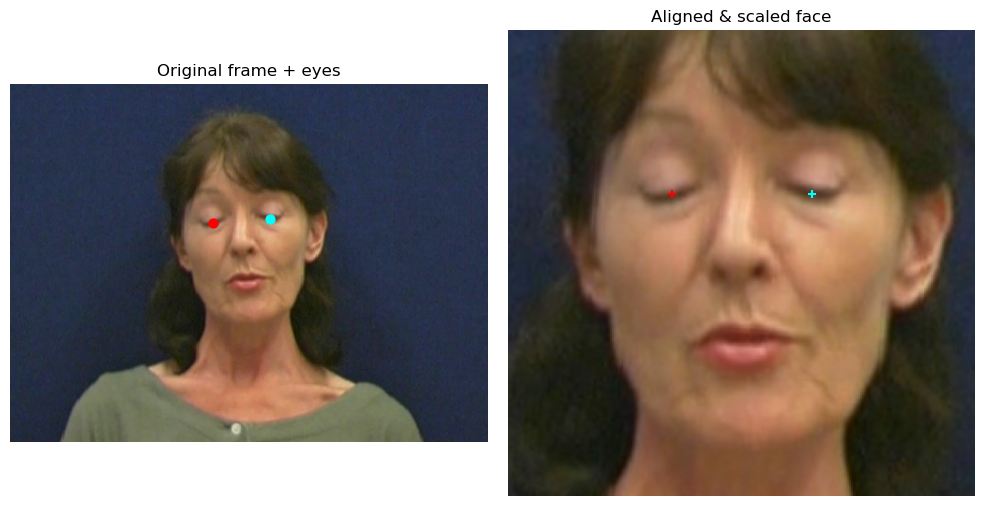

In [7]:
sample_video = str(REAL_DIR / "fadg0" / "sa1.avi")
cap = cv2.VideoCapture(sample_video)
cap.set(cv2.CAP_PROP_POS_FRAMES, 60)
ok, frame_bgr = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

face = detect_faces(frame_rgb)[0]
eyes = (face["left_eye"], face["right_eye"])
aligned = crop_and_align(DESIRED_SIZE, DESIRED_LEFT_EYE, frame_rgb, eyes)

print("Eye tilt angle : %.2f deg" % eyes_angle(*eyes))
print("Aligned shape  :", aligned.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(frame_rgb)
for (ex, ey), c in zip(eyes, ["red", "cyan"]):
    ax[0].scatter([ex], [ey], c=c, s=40)
ax[0].set_title("Original frame + eyes"); ax[0].axis("off")
ax[1].imshow(aligned)
# mark where the eyes are supposed to be in the output
for rx, cc in zip([DESIRED_LEFT_EYE[0], 1 - DESIRED_LEFT_EYE[0]], ["red", "cyan"]):
    ax[1].scatter([rx * DESIRED_SIZE[0]], [DESIRED_LEFT_EYE[1] * DESIRED_SIZE[1]],
                  c=cc, s=40, marker="+")
ax[1].set_title("Aligned & scaled face"); ax[1].axis("off")
plt.tight_layout(); plt.show()

### Sanity check: do the eyes land where we asked?

Transform the eye coordinates through the same matrix and confirm they hit the target output pixels and
share the same y (i.e. are level).

In [8]:
angle = eyes_angle(*eyes)
current_dist = hypot(eyes[1][0]-eyes[0][0], eyes[1][1]-eyes[0][1])
scale = scaling_factor(current_dist, 1 - 2*DESIRED_LEFT_EYE[0], DESIRED_SIZE[0])
center = ((eyes[0][0]+eyes[1][0])/2, (eyes[0][1]+eyes[1][1])/2)
M = cv2.getRotationMatrix2D(center, angle, scale)
M[0, 2] += DESIRED_SIZE[0]*0.5 - center[0]
M[1, 2] += DESIRED_SIZE[1]*DESIRED_LEFT_EYE[1] - center[1]

def transform(pt): return (M[0,0]*pt[0]+M[0,1]*pt[1]+M[0,2], M[1,0]*pt[0]+M[1,1]*pt[1]+M[1,2])
tl, tr = transform(eyes[0]), transform(eyes[1])
print("left  eye ->", tuple(round(v,1) for v in tl),
      " target", (round(DESIRED_LEFT_EYE[0]*DESIRED_SIZE[0],1), round(DESIRED_LEFT_EYE[1]*DESIRED_SIZE[1],1)))
print("right eye ->", tuple(round(v,1) for v in tr),
      " target", (round((1-DESIRED_LEFT_EYE[0])*DESIRED_SIZE[0],1), round(DESIRED_LEFT_EYE[1]*DESIRED_SIZE[1],1)))
print("eyes level? dy =", round(tl[1]-tr[1], 4))

left  eye -> (89.6, 89.6)  target (89.6, 89.6)
right eye -> (166.4, 89.6)  target (166.4, 89.6)
eyes level? dy = 0.0


## Align every face in a video and save to disk

Face detection + alignment is slow, so we persist the aligned faces as JPEGs for reuse.

In [9]:
def align_and_save(video_path, out_dir, desired_size=DESIRED_SIZE, desired_left_eye=DESIRED_LEFT_EYE):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    saved, idx = 0, 0
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        image_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        for j, f in enumerate(detect_faces(image_rgb)):
            aligned = crop_and_align(desired_size, desired_left_eye,
                                     image_rgb, (f["left_eye"], f["right_eye"]))
            cv2.imwrite(str(out_dir / f"frame{idx:04d}_face{j}.jpg"),
                        cv2.cvtColor(aligned, cv2.COLOR_RGB2BGR))
            saved += 1
        idx += 1
    cap.release()
    return saved

aligned_dir = root / "Data" / "faces_aligned" / "fadg0_sa1_real"
n = align_and_save(sample_video, aligned_dir)
print(f"Saved {n} aligned faces to {aligned_dir}")

Saved 119 aligned faces to /Users/blake/AI Projects/Deepfake-Detection/Data/faces_aligned/fadg0_sa1_real


### The payoff: uniformity

Every saved face is now the same size with the eyes in the same place. Displaying a grid makes the
consistency obvious — exactly what downstream classification/recognition needs.

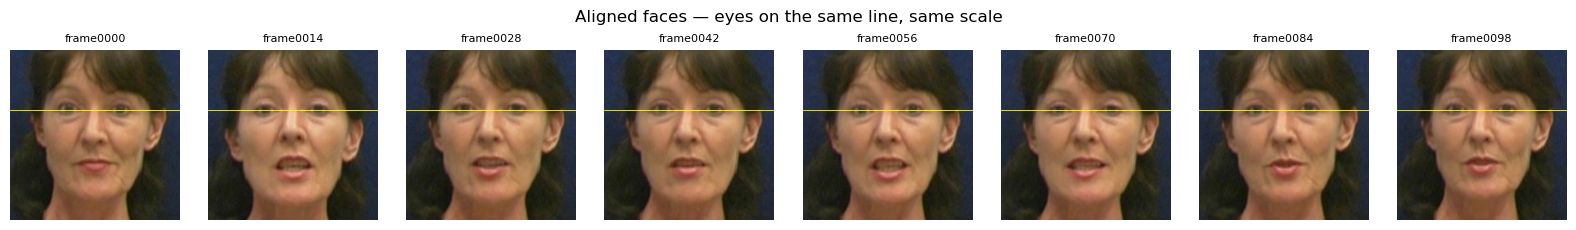

In [10]:
files = sorted(glob.glob(str(aligned_dir / "*.jpg")))
picks = files[::max(1, len(files)//8)][:8]
fig, axes = plt.subplots(1, len(picks), figsize=(2*len(picks), 2.3))
for ax, fp in zip(np.atleast_1d(axes), picks):
    ax.imshow(cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB))
    ax.axhline(DESIRED_LEFT_EYE[1]*DESIRED_SIZE[1], color="yellow", lw=0.6)  # eye line
    ax.set_title(Path(fp).stem.split("_")[0], fontsize=8); ax.axis("off")
plt.suptitle("Aligned faces — eyes on the same line, same scale"); plt.tight_layout(); plt.show()

## Summary

- **`eyes_angle()`**, **`scaling_factor()`**, and **`crop_and_align()`** together rotate each face so the
  eyes are horizontal, scale it so the inter-eye distance matches the target, and warp it into a fixed
  `DESIRED_SIZE` canvas with the eyes at `DESIRED_LEFT_EYE`.
- Verified numerically that the eyes land on their target pixels and are perfectly level.
- Aligned faces are saved to `Data/faces_aligned/`, giving a uniform set ready for the next stage.

The same pipeline runs on the deepfake videos — point `sample_video` at a clip under
`Data/DeepfakeTIMIT/higher_quality/` to build aligned fake faces the same way.